# Testing new data

## Data loading

In [2]:
import pandas as pd
# Import data
df_raw = pd.read_excel('../DataNew/UFM_cleaned.xlsx', header=0)

# Columns to keep
cols = [
    'udbud_id',
    'titel',
    'educational_category',
    'displaydocclass',
    'hovedinsttx',
    'instregiontx',
    'instkommunetx',
    'arbejdstid_timer',
    'arbmedstud_likert',
    'ensom_likert',
    'maanedloen_10aar',
    'maanedloen_nyudd',
    'tidsforbrug_p50',
]

data = df_raw[cols]

# Remove all udbud_id==999999, as this is the education on national level
data_whole_edu = data[data['udbud_id'] == 999999]
data = data[data['udbud_id'] != 999999]

# Remove the udbud_id column
data = data.drop(columns=['udbud_id'])

data_na = data.copy()
# Remove all rows with missing values
data = data.dropna()

In [8]:
data

,titel,educational_category,displaydocclass,hovedinsttx,instregiontx,instkommunetx,arbejdstid_timer,arbmedstud_likert,ensom_likert,maanedloen_10aar,maanedloen_nyudd,tidsforbrug_p50
8,Administrationsøkonom,Erhvervsakademiuddannelser,Erhvervsakademiuddannelse,Zealand Sjællands Erhvervsakademi,Sjælland,Køge,37.0,"4,13","4,17",37.00,32.30,"36,0"
11,Psykomotorisk terapeut,Professionsbacheloruddannelser,Professionsbacheloruddannelse,Københavns Professionshøjskole,Hovedstaden,Hillerød,34.0,"3,88","3,70",24.70,32.40,"40,0"
19,Automationsteknolog,Erhvervsakademiuddannelser,Erhvervsakademiuddannelse,Professionshøjskolen University College Nordjy...,Nordjylland,Aalborg,38.0,"4,09","3,84",48.25,41.65,"41,0"
38,Bioanalytiker,Professionsbacheloruddannelser,Professionsbacheloruddannelse,Københavns Professionshøjskole,Hovedstaden,København,37.0,"3,81","3,65",38.50,32.30,"39,0"
41,Bioanalytiker,Professionsbacheloruddannelser,Professionsbacheloruddannelse,Professionshøjskolen UC Syddanmark,Syddanmark,Esbjerg,38.0,"3,96","3,95",36.60,31.00,"42,0"
...,...,...,...,...,...,...,...,...,...,...,...,...
2049,Politik og forvaltning,Kandidatuddannelser,Kandidatuddannelse,Roskilde Universitet,Sjælland,Roskilde,39.0,"3,69","3,19",54.60,37.90,"29,0"
2051,Samfundsvidenskabelig jura,Kandidatuddannelser,Kandidatuddannelse,Københavns Universitet,Hovedstaden,København,39.0,"3,85","3,85",47.60,41.70,"31,5"
2057,Socialvidenskab,Kandidatuddannelser,Kandidatuddannelse,Roskilde Universitet,Sjælland,Roskilde,36.0,"4,10","3,79",48.60,36.25,"30,0"
2061,Tværvidenskabelige sundhedsstudier,Kandidatuddannelser,Kandidatuddannelse,Roskilde Universitet,Sjælland,Roskilde,37.0,"4,24","3,88",47.30,36.60,"37,5"


displaydocclass
Kandidatuddannelse                        825
Bacheloruddannelse                        544
Professionsbacheloruddannelse             368
Erhvervsakademiuddannelse                 216
Professionsbacheloruddannelse (top-up)     84
Anden uddannelse                           64
Politi og forsvar                          13
Name: count, dtype: int64


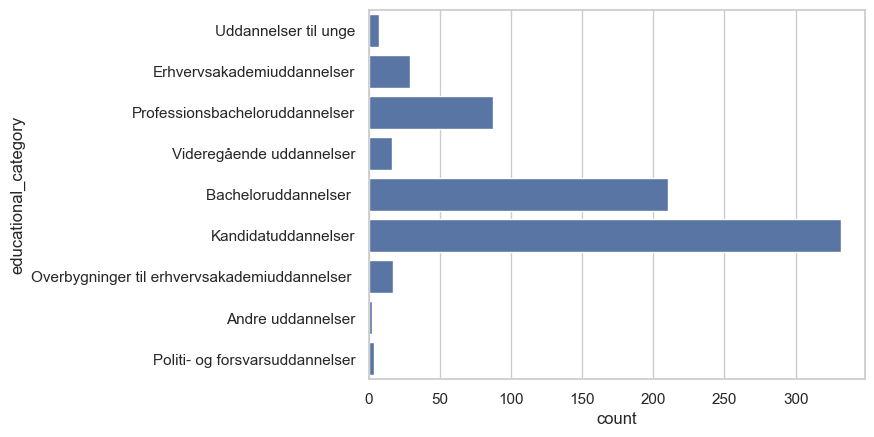

In [25]:
import seaborn as sns

sns.countplot(data=data_whole_edu, y='educational_category')
print(counts)

In [27]:
data_whole_edu['displaydocclass'].value_counts()

displaydocclass
Kandidatuddannelse                        332
Bacheloruddannelse                        208
Professionsbacheloruddannelse              87
Erhvervsakademiuddannelse                  29
Anden uddannelse                           27
Professionsbacheloruddannelse (top-up)     17
Politi og forsvar                           4
Name: count, dtype: int64

In [28]:
data_whole_edu['educational_category'].value_counts()

educational_category
Kandidatuddannelser                              332
Bacheloruddannelser                              210
Professionsbacheloruddannelser                    87
Erhvervsakademiuddannelser                        29
Overbygninger til erhvervsakademiuddannelser      17
Videregående uddannelser                          16
Uddannelser til unge                               7
Politi- og forsvarsuddannelser                     4
Andre uddannelser                                  2
Name: count, dtype: int64

In [29]:
data_whole_edu_2 = data_whole_edu[data_whole_edu['educational_category']!='Kandidatuddannelser']

In [30]:
data_whole_edu_2['educational_category'].value_counts()

educational_category
Bacheloruddannelser                              210
Professionsbacheloruddannelser                    87
Erhvervsakademiuddannelser                        29
Overbygninger til erhvervsakademiuddannelser      17
Videregående uddannelser                          16
Uddannelser til unge                               7
Politi- og forsvarsuddannelser                     4
Andre uddannelser                                  2
Name: count, dtype: int64

In [31]:
len(data_whole_edu_2)

372

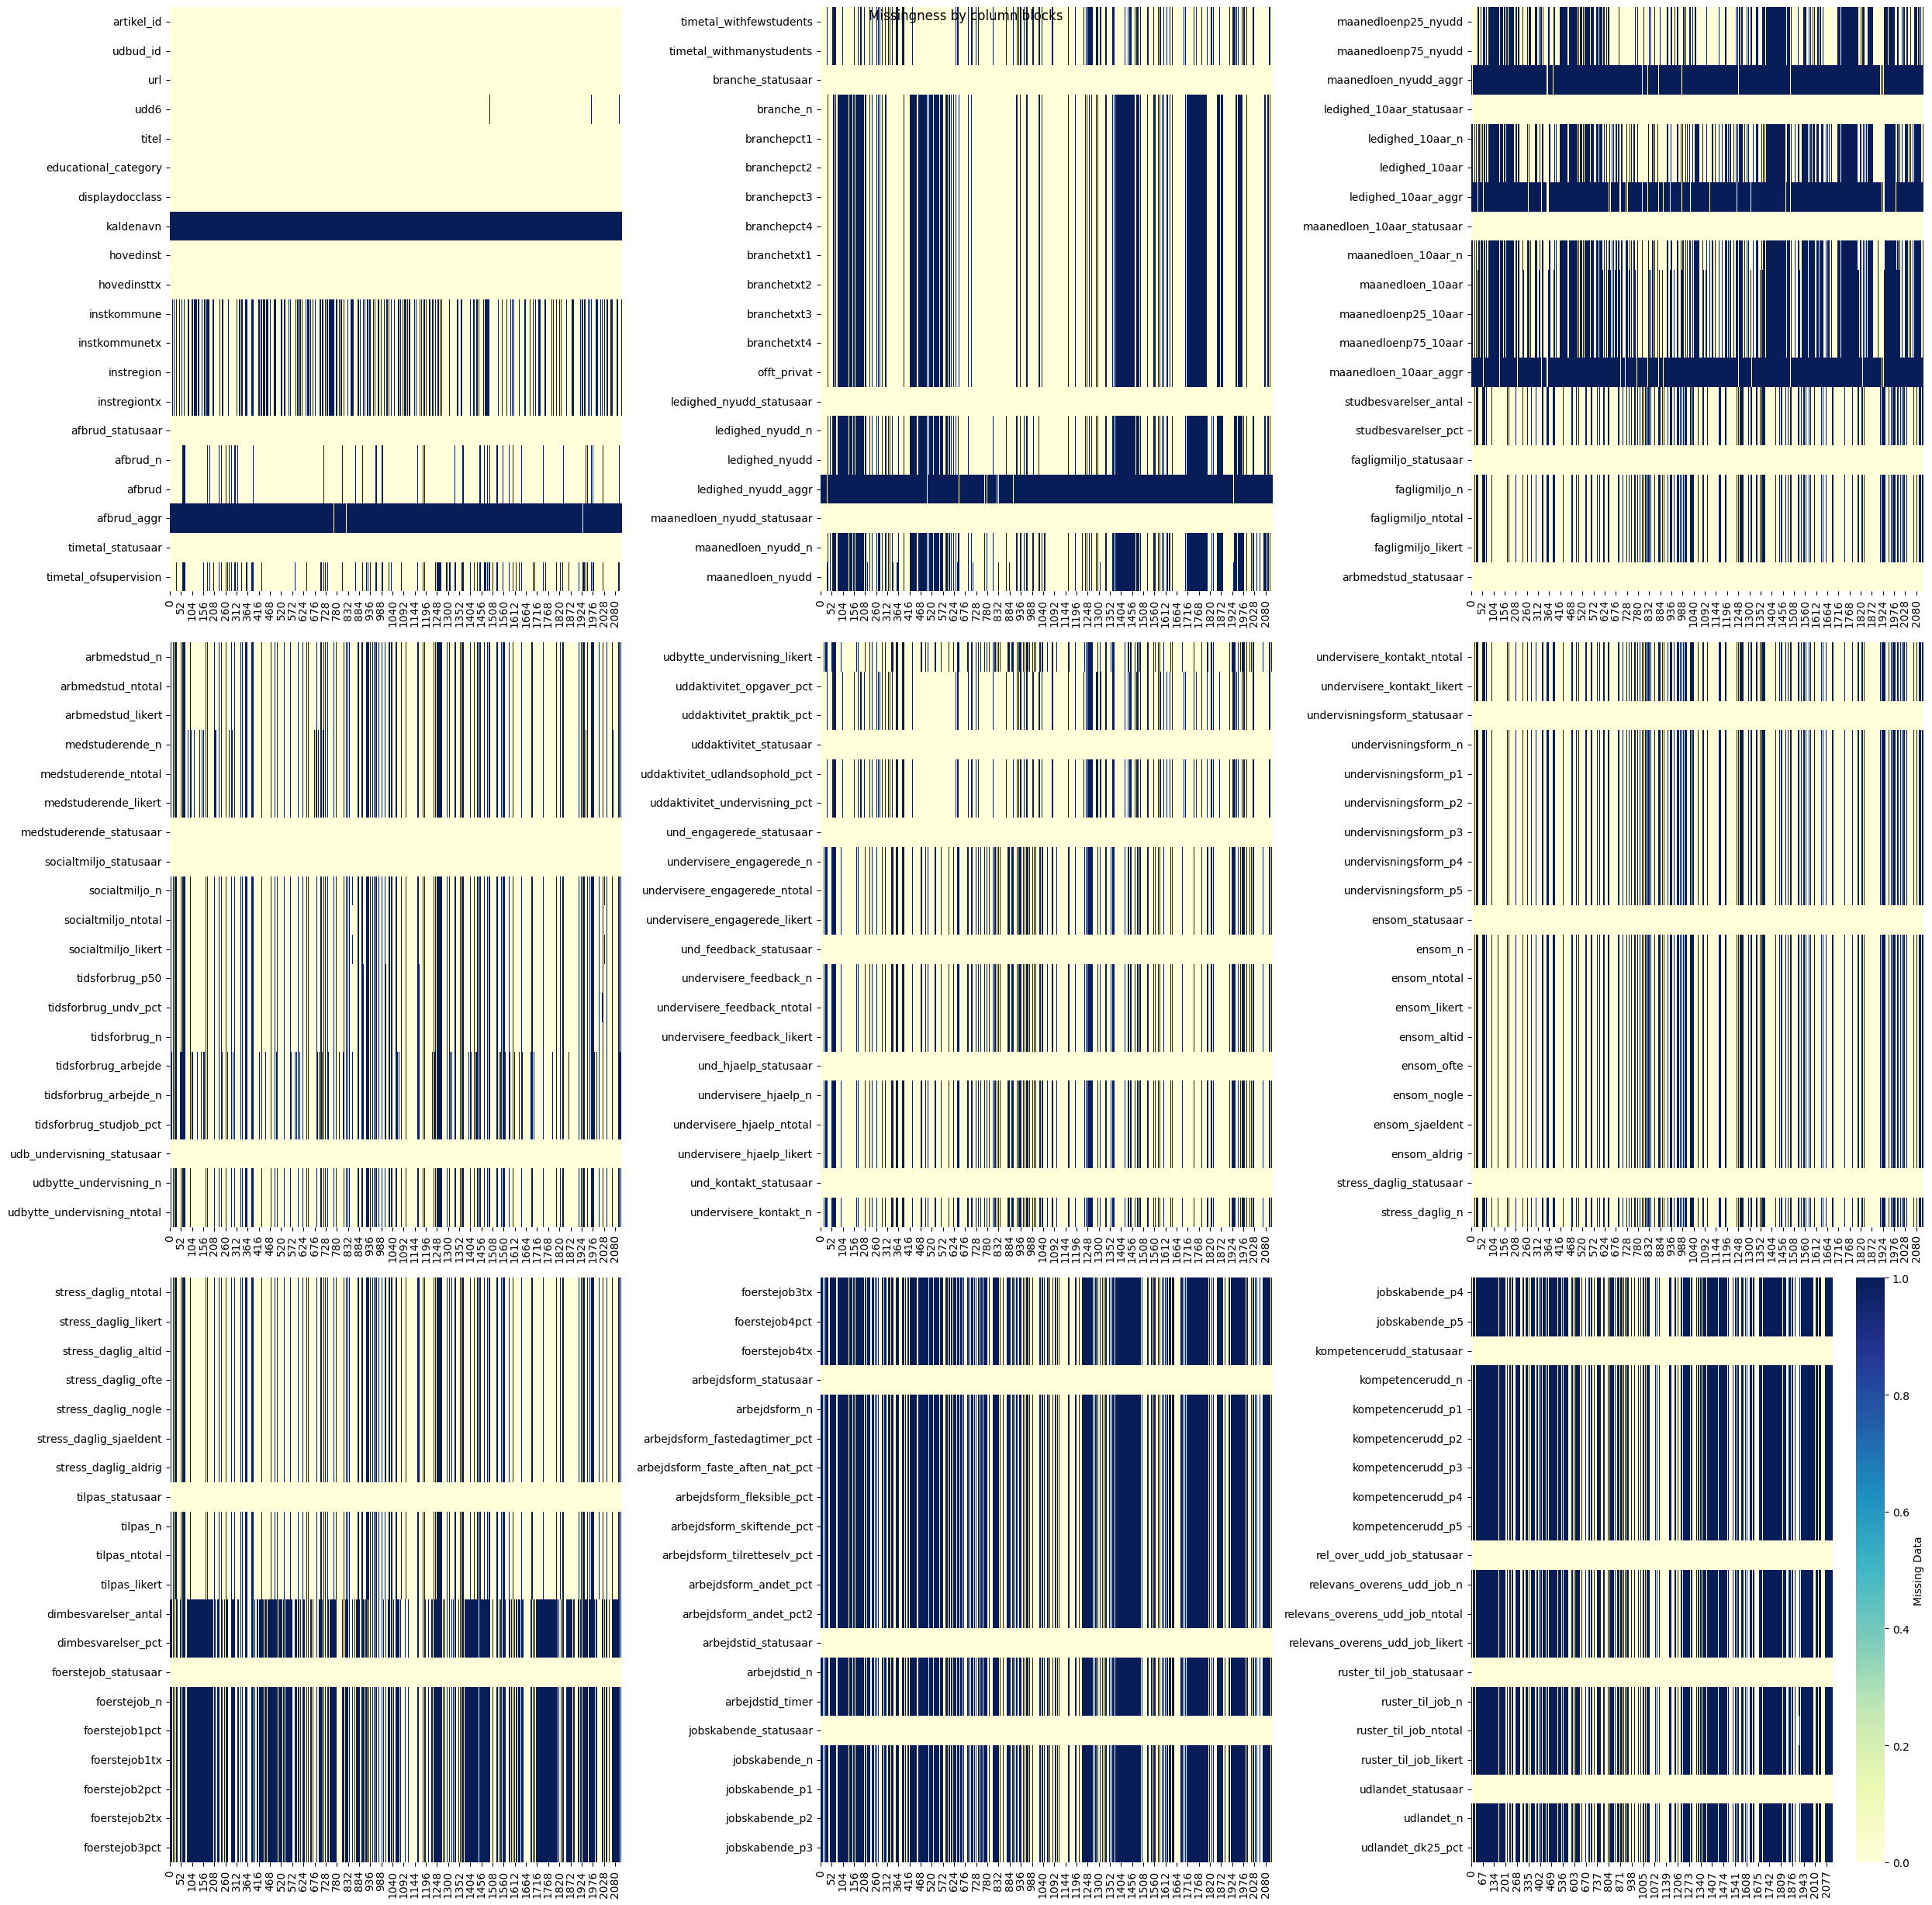

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make 9 subplots with
fig, axs = plt.subplots(3, 3, figsize=(25, 25))
for i in range(9):
    ax = axs[i // 3, i % 3]
    data_block = df_raw.iloc[:, i*20:(i+1)*20].isna().transpose()
    # Draw heatmap on the specific subplot axis. Show a single colorbar on the last subplot to avoid overlap.
    if i == 8:
        sns.heatmap(data_block, cmap="YlGnBu", ax=ax, cbar_kws={'label': 'Missing Data'})
    else:
        sns.heatmap(data_block, cmap="YlGnBu", ax=ax, cbar=False)

fig.suptitle('Missingness by column blocks')
fig.tight_layout()

In [11]:
df_raw.iloc[:, :20].isna()

,artikel_id,udbud_id,url,udd6,titel,educational_category,displaydocclass,kaldenavn,hovedinst,hovedinsttx,instkommune,instkommunetx,instregion,instregiontx,afbrud_statusaar,afbrud_n,afbrud,afbrud_aggr,timetal_statusaar,timetal_ofsupervision
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True
1,False,False,False,False,False,False,False,True,False,False,True,True,True,True,False,False,False,True,False,True
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,True,False,True
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2109,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2110,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2111,False,False,False,False,False,False,False,True,False,False,True,True,True,True,False,False,False,True,False,False
2112,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
